## Recurrent All-Pairs Field Transforms (RAFT)

### What This Notebook Does
This notebook runs **RAFT** : the state-of-the-art deep learning optical flow method on the same KITTI pairs from Classical Methods Notebook. We use pretrained weights (no training needed).

RAFT introduced 3 key innovations:
1. **All-pairs correlation** : compares EVERY pixel in frame1 with EVERY pixel in frame2 -> 4D correlation volume
2. **Recurrent update** : like GRU/LSTM, it iteratively refines flow predictions
3. **Single resolution** : no pyramid needed, handles all motion scales


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Verify KITTI DataSet
import os

KITTI_ROOT = '/content/drive/MyDrive/OpticalFlow/KITTI'

if os.path.exists(KITTI_ROOT):
    print('KITTI folder found at:', KITTI_ROOT)
    print('Contents:', os.listdir(KITTI_ROOT)[:10])
else:
    print('KITTI folder NOT found.')




Mounted at /content/drive
KITTI folder found at: /content/drive/MyDrive/OpticalFlow/KITTI
Contents: ['training']


## Install RAFT

RAFT's official implementation is on GitHub. We clone it and use its pretrained weights.

### Why Use Pretrained Weights?
Training RAFT from scratch requires:
- FlyingChairs + FlyingThings3D datasets (hundreds of GB)
- Multiple days of GPU training

Using pretrained weights = research-standard practice (transfer learning).



In [3]:
# INSTALL RAFT
import os

# Base directory — everything lives here
OPTFLOW_DIR = '/content/drive/MyDrive/OpticalFlow'
RAFT_DIR    = f'{OPTFLOW_DIR}/RAFT'
RAFT_LOCAL  = '/content/RAFT'

# Clone official RAFT repository (Princeton) to Drive for persistence
if not os.path.exists(RAFT_DIR):
    print("Cloning RAFT repository...")
    os.system(f'git clone https://github.com/princeton-vl/RAFT.git {RAFT_DIR}')
    print("RAFT cloned to Drive")
else:
    print("RAFT already exists on Drive")

# Symlink Drive copy to /content/RAFT so RAFT imports work correctly
if not os.path.exists(RAFT_LOCAL):
    os.system(f'ln -s {RAFT_DIR} {RAFT_LOCAL}')
    print("Symlink created")

# Install dependencies
os.system('pip install -q einops timm')
print("Dependencies installed")

RAFT already exists on Drive
Symlink created
Dependencies installed


In [4]:
# DOWNLOAD RAFT PRETRAINED WEIGHTS
import os

# Weights stored in Drive so they persist across sessions
WEIGHTS_DIR  = f'{OPTFLOW_DIR}/RAFT/models'
WEIGHTS_PATH = f'{WEIGHTS_DIR}/raft-kitti.pth'
FALLBACK_PATH = f'{WEIGHTS_DIR}/raft-things.pth'

# Local symlinked path : RAFT code expects weights here
LOCAL_WEIGHTS_DIR = '/content/RAFT/models'

os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(LOCAL_WEIGHTS_DIR, exist_ok=True)

# Install gdown for downloading from Google Drive
os.system('pip install -q gdown')

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading RAFT-KITTI pretrained weights...")

    # Official weights from RAFT authors (Princeton)
    # raft-kitti.pth : fine-tuned on KITTI, best for our evaluation
    os.system(
        f'gdown https://drive.google.com/uc?id=1MqDajR89k-xLV0HIrmJ0k-n8ZpG6_suM '
        f'-O {WEIGHTS_PATH}'
    )

    if os.path.exists(WEIGHTS_PATH):
        size_mb = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)
        print(f"Downloaded RAFT-KITTI weights ({size_mb:.1f} MB)")
    else:
        # Fallback to raft-things if kitti download fails
        print("KITTI weights download failed — trying raft-things as fallback...")
        os.system(
            f'gdown https://drive.google.com/uc?id=1iHSABMkKDEoW_nCJHg7fYZAqe9oR6CPj '
            f'-O {FALLBACK_PATH}'
        )
        WEIGHTS_PATH = FALLBACK_PATH
        print("Using raft-things.pth as fallback")
else:
    print(f"Weights already downloaded: {WEIGHTS_PATH}")

# Symlink weights to local RAFT directory so RAFT code can find them
LOCAL_WEIGHTS_PATH = f'{LOCAL_WEIGHTS_DIR}/raft-kitti.pth'
if not os.path.exists(LOCAL_WEIGHTS_PATH):
    os.system(f'ln -s {WEIGHTS_PATH} {LOCAL_WEIGHTS_PATH}')

print(f"\nUsing weights: {WEIGHTS_PATH}")

Weights already downloaded: /content/drive/MyDrive/OpticalFlow/RAFT/models/raft-kitti.pth

Using weights: /content/drive/MyDrive/OpticalFlow/RAFT/models/raft-kitti.pth


In [5]:
# IMPORTS
import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
import glob
import json
from pathlib import Path

# Add RAFT to Python path so we can import its modules
# RAFT code lives in /content/RAFT/core — Python doesn't know this by default
sys.path.insert(0, '/content/RAFT/core')

# Import RAFT model and utilities
from raft import RAFT
from utils import flow_viz           # RAFT's built-in flow visualization
from utils.utils import InputPadder  # Pads images to be divisible by 8

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found : RAFT will run on CPU (slower)")

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['figure.dpi'] = 100

print(f"PyTorch version: {torch.__version__}")

Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB
PyTorch version: 2.11.0+cu128


##Load RAFT Model

Understanding RAFT Architecture

```
Frame 1, Frame 2
    ↓
[Feature Encoder] → extracts features from both frames (ResNet-like)
    ↓
[4D Correlation Volume] → compares ALL pairs of features
    ↓
[Recurrent Update (GRU)] → iteratively refines flow prediction
    ↓                        
[Flow Prediction] → final dense flow field
```

The `small=False` flag loads the full RAFT model (5.3M parameters).
The `small=True` flag loads RAFT-Small (1M parameters, faster but less accurate).

In [6]:
# LOAD RAFT MODEL

class Args:
    """RAFT configuration object."""
    small           = False
    mixed_precision = False
    alternate_corr  = False
    dropout         = 0

    def __contains__(self, key):
        # Allows 'dropout' in args to work correctly
        return hasattr(self, key)


def load_raft_model(weights_path, device):
    """
    Initialize RAFT and load pretrained weights.
    Strips DataParallel 'module.' prefix added during multi-GPU training.
    """
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Weights not found: {weights_path}")

    model = RAFT(Args())

    pretrained_weights = torch.load(weights_path, map_location=device)

    # Strip 'module.' prefix added by DataParallel during training
    new_weights = {
        key.replace('module.', ''): value
        for key, value in pretrained_weights.items()
    }

    model.load_state_dict(new_weights)
    model = model.to(device)
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    print(f"RAFT loaded : {total_params/1e6:.1f}M parameters on {device}")

    return model


model = load_raft_model(WEIGHTS_PATH, device)

RAFT loaded : 5.3M parameters on cuda


##RAFT Inference Pipeline

### How RAFT Processes Images

1. **Load images** : standard RGB images
2. **Pad images** : RAFT requires dimensions divisible by 8
3. **Convert to tensor** : PyTorch tensor, normalized to [0, 255]
4. **Run RAFT** : with `iters=20` refinement iterations
5. **Get flow** : RAFT outputs flow in pixels/frame

### The `iters` Parameter
This is the **recurrent refinement** steps. More iterations = more accurate but slower.
- `iters=12` : fast mode
- `iters=20` : standard (we use this)
- `iters=32` : high accuracy mode

In [7]:
# RAFT INFERENCE FUNCTIONS

def preprocess_for_raft(frame_rgb, device):
    """
    Convert RGB numpy array (H,W,3) to RAFT tensor (1,3,H,W).
    RAFT expects float32 values in range [0, 255] : not normalized to [0,1].
    """
    # numpy is HWC (Height, Width, Channels)
    # PyTorch expects CHW (Channels, Height, Width)
    # permute(2, 0, 1) reorders axes: HWC → CHW
    tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float()

    # RAFT expects a batch dimension — unsqueeze adds it
    # CHW → NCHW where N=1 (single image batch)
    tensor = tensor.unsqueeze(0)

    return tensor.to(device)


@torch.no_grad() # we never need gradients. Like we don't need them.
def compute_raft_flow(model, frame1, frame2, device, iters=20):

    img1_tensor = preprocess_for_raft(frame1, device)
    img2_tensor = preprocess_for_raft(frame2, device)

    # RAFT downsamples 3 times (8x total reduction)
    # Image dimensions must be divisible by 8
    # InputPadder pads to nearest multiple of 8 then crops back after
    padder = InputPadder(img1_tensor.shape)
    img1_padded, img2_padded = padder.pad(img1_tensor, img2_tensor)

    # RAFT returns one flow prediction per iteration
    # Later iterations are more refined : take the last one
    flow_predictions = model(img1_padded, img2_padded, iters=iters, test_mode=True)

    flow_tensor = flow_predictions[-1] if isinstance(flow_predictions, (list, tuple)) else flow_predictions

    # Remove padding added by InputPadder
    flow_tensor = padder.unpad(flow_tensor)

    # Convert tensor (1, 2, H, W) -> numpy (H, W, 2)
    # squeeze(0) -> (2, H, W)   remove batch dimension
    # .cpu() ->  move from GPU to CPU
    # .numpy() -> convert to numpy array
    # .transpose() -> (2, H, W) -> (H, W, 2)
    return flow_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)


def flow_to_hsv_visualization(flow):
    """
    Convert dense flow field to HSV color image.
    Hue = direction, Saturation = speed, Value = 255.
    """
    u = flow[:, :, 0]
    v = flow[:, :, 1]

    magnitude = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v, u)

    hsv  = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[:, :, 0] = ((angle + np.pi) / (2 * np.pi) * 180).astype(np.uint8)

    max_mag = magnitude.max()
    if max_mag > 0:
        hsv[:, :, 1] = (magnitude / max_mag * 255).astype(np.uint8)

    hsv[:, :, 2] = 255

    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


print("RAFT inference functions defined")

RAFT inference functions defined


## Run RAFT on KITTI

Now we run RAFT on the same image pairs as Classical Algorithms Notebook.
This allows direct comparison between classical and deep learning methods.

In [15]:
# SETUP PATHS
import glob

# All paths derived from OPTFLOW_DIR defined in configuration cell
IMAGE_FOLDER = "image_1"
COLOR_FOLDER = "colored_1"

IMAGE_DIR  = f'{OPTFLOW_DIR}/KITTI/training/{IMAGE_FOLDER}'
COLOR_DIR  = f'{OPTFLOW_DIR}/KITTI/training/{COLOR_FOLDER}'
FLOW_DIR   = f'{OPTFLOW_DIR}/KITTI/training/flow_occ'
OUTPUT_DIR = f'{OPTFLOW_DIR}/results'

os.makedirs(f'{OUTPUT_DIR}/raft', exist_ok=True)


def load_image(path):
    """Load image from disk and return as RGB numpy array (H,W,3)."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def get_image_pairs(image_dir, max_pairs=10):
    """Return list of (frame1_path, frame2_path) tuples from KITTI directory."""
    frame1_files = sorted(glob.glob(os.path.join(image_dir, "*_10.png")))
    pairs = []
    for f1_path in frame1_files[:max_pairs]:
        f2_path = f1_path.replace("_10.png", "_11.png")
        if os.path.exists(f2_path):
            pairs.append((f1_path, f2_path))
    return pairs


if not os.path.exists(IMAGE_DIR):
    raise RuntimeError(f"IMAGE_DIR not found: {IMAGE_DIR}")

pairs = get_image_pairs(IMAGE_DIR, max_pairs=10)

if not pairs:
    raise RuntimeError(f"No image pairs found in {IMAGE_DIR}")

print(f"Found {len(pairs)} image pairs")

Found 10 image pairs



Pair 1/5: 000000_10.png


/content/RAFT/core/raft.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/RAFT/core/raft.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/content/RAFT/core/raft.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


Flow shape    : (370, 1226, 2)
Inference time: 1.671s
Mean magnitude: 47.234 px/frame
Max magnitude : 164.482 px/frame


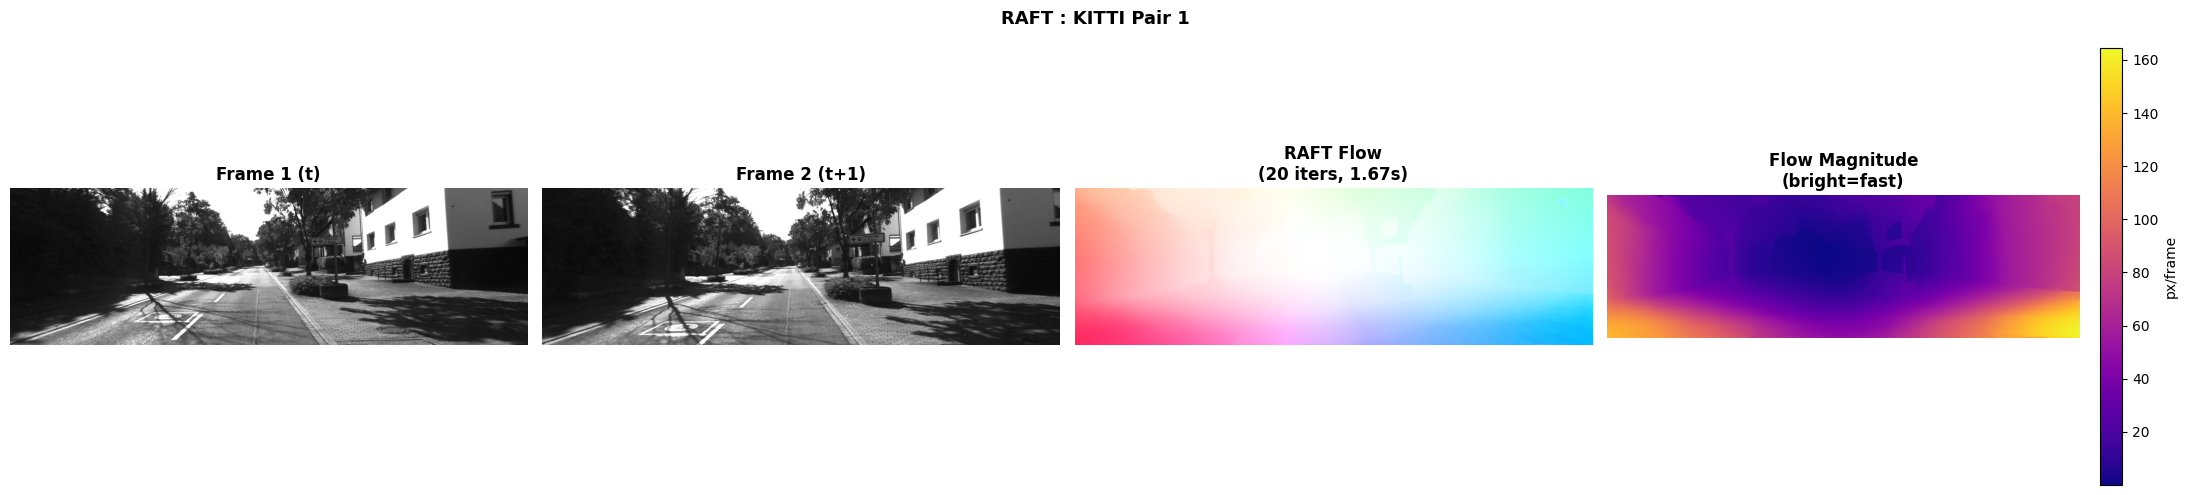


Pair 2/5: 000001_10.png
Flow shape    : (370, 1226, 2)
Inference time: 0.469s
Mean magnitude: 68.753 px/frame
Max magnitude : 152.111 px/frame


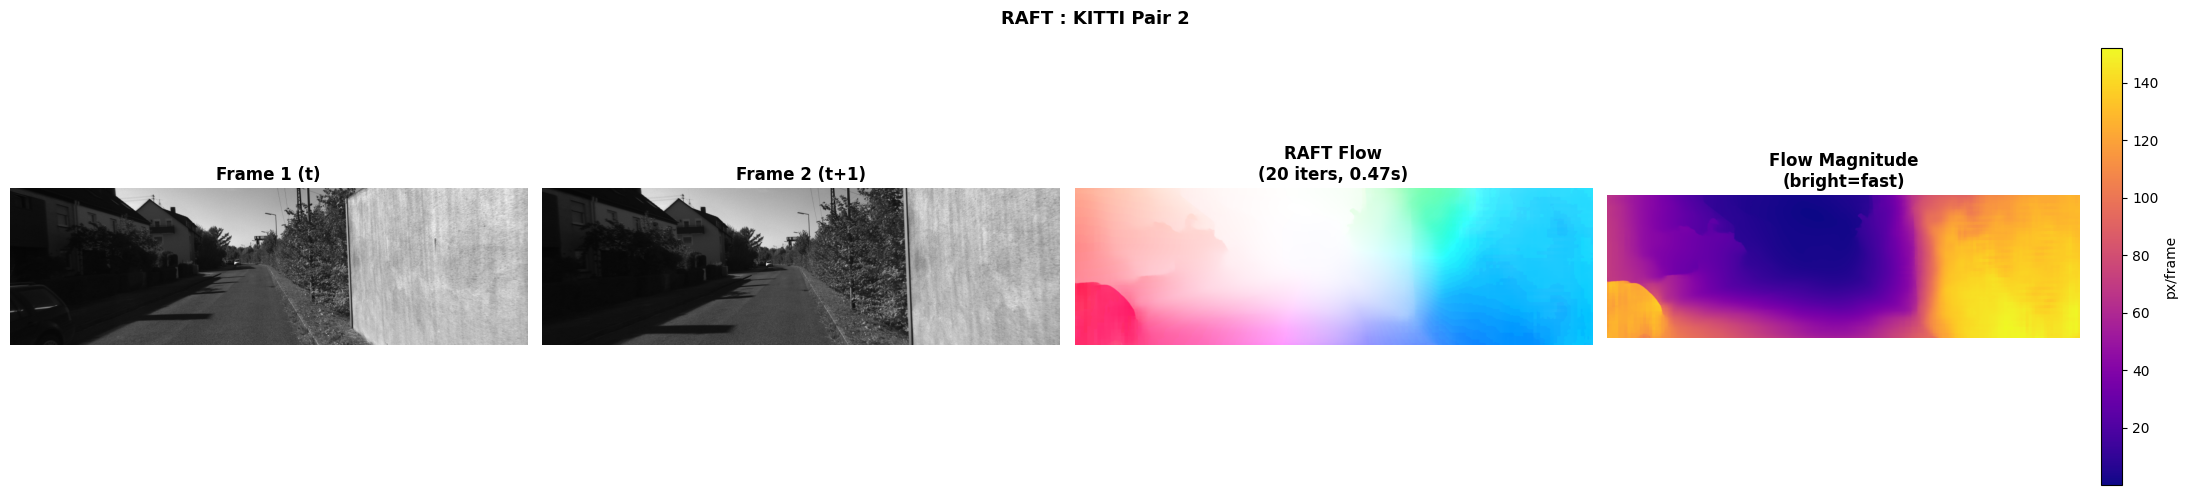


Pair 3/5: 000002_10.png
Flow shape    : (376, 1241, 2)
Inference time: 0.439s
Mean magnitude: 60.232 px/frame
Max magnitude : 210.547 px/frame


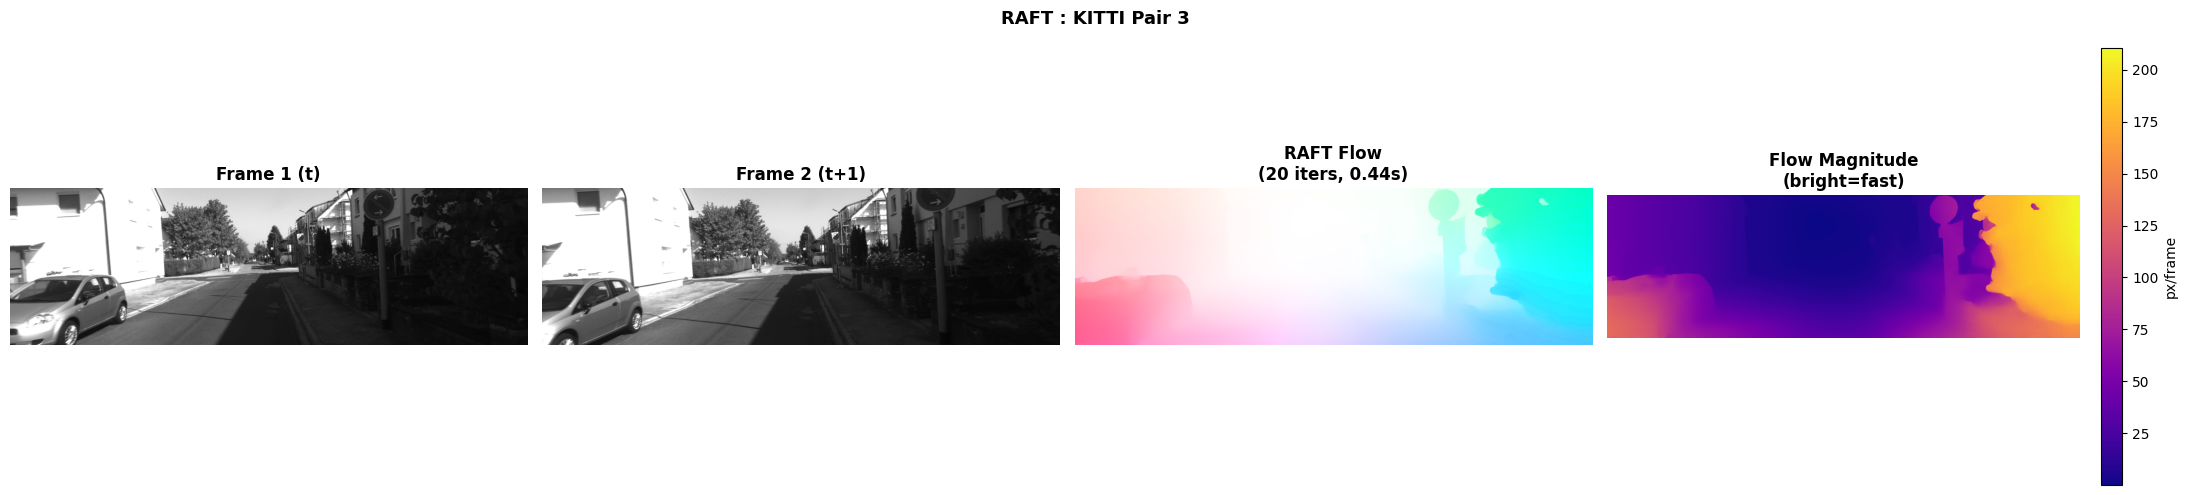


Pair 4/5: 000003_10.png
Flow shape    : (375, 1242, 2)
Inference time: 0.403s
Mean magnitude: 29.722 px/frame
Max magnitude : 129.068 px/frame


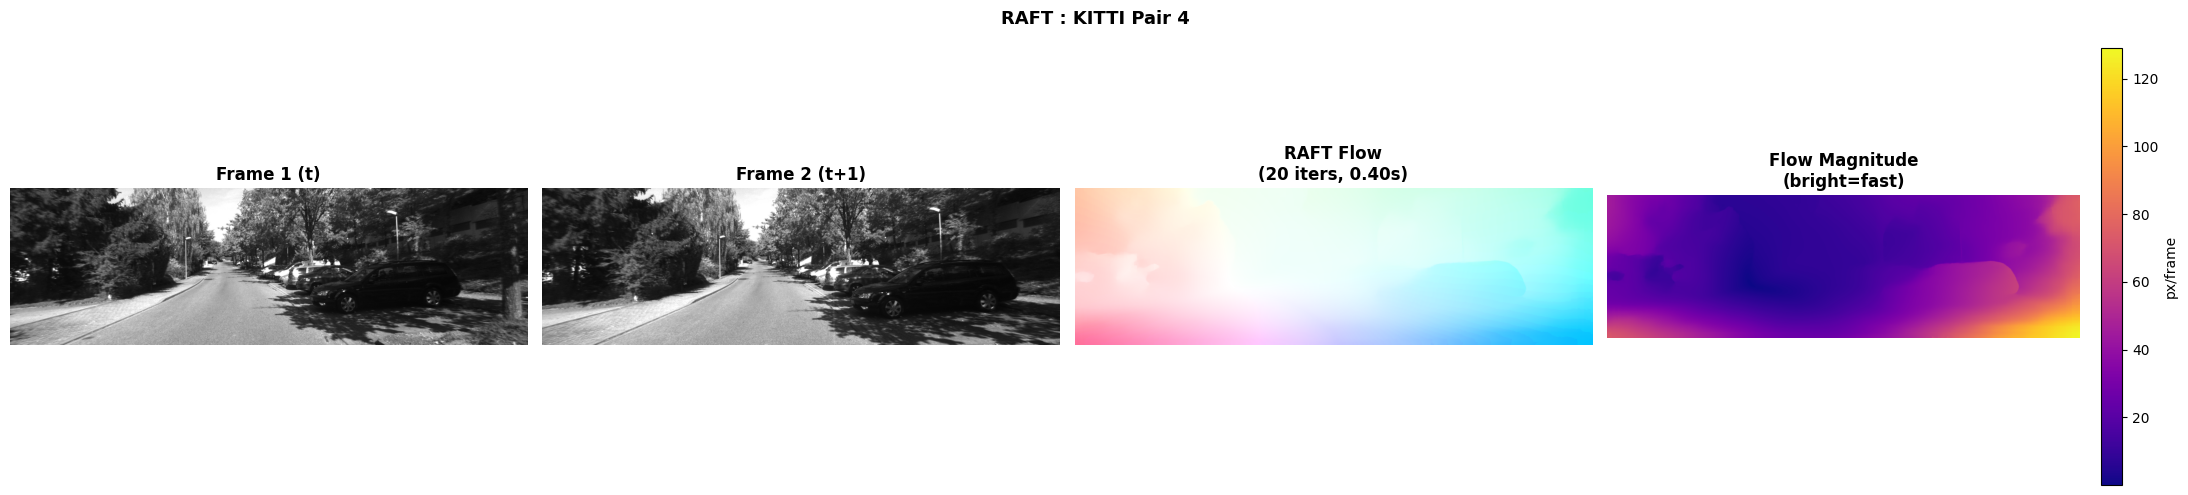


Pair 5/5: 000004_10.png
Flow shape    : (376, 1241, 2)
Inference time: 0.455s
Mean magnitude: 45.767 px/frame
Max magnitude : 118.373 px/frame


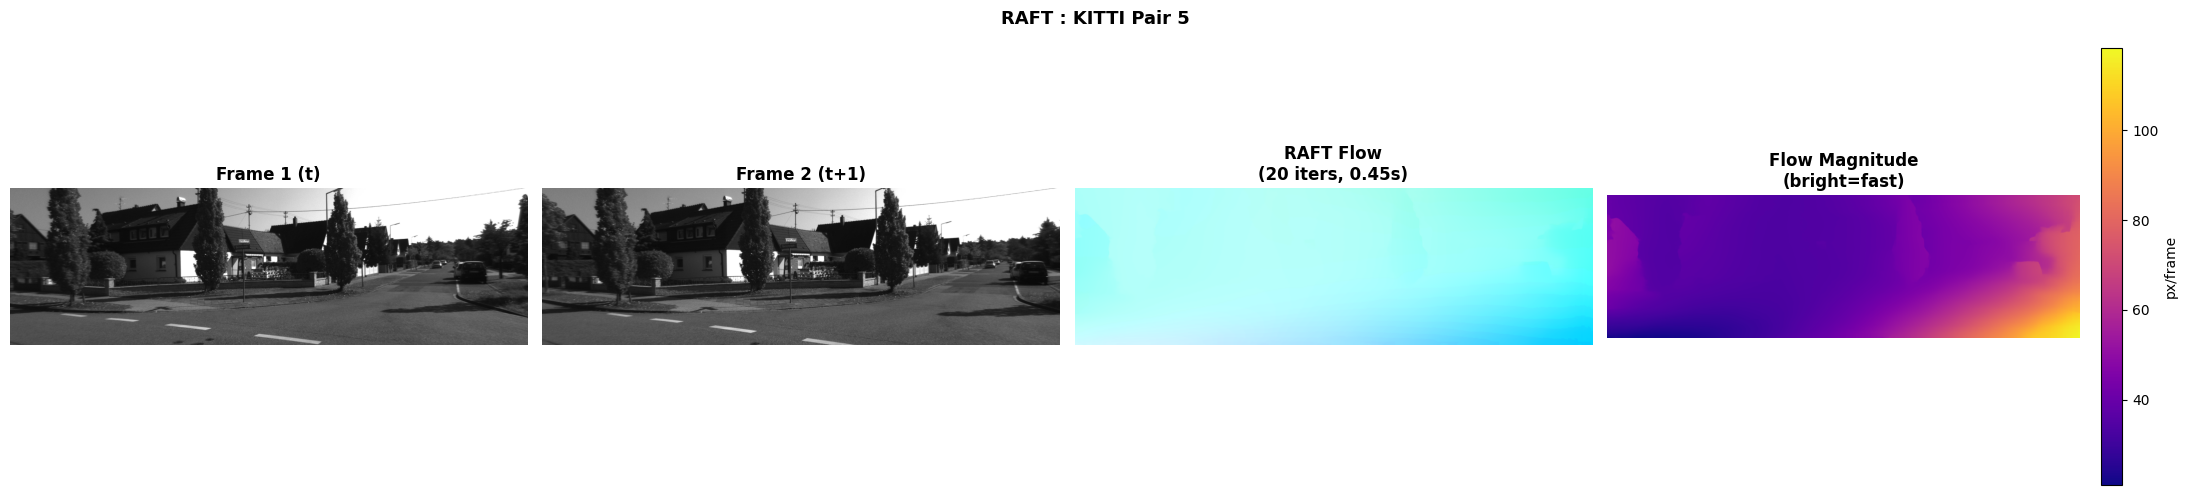

RAFT inference complete


In [16]:
# RUN RAFT ON KITTI PAIRS
import time

raft_results = []

for i, (f1_path, f2_path) in enumerate(pairs[:5]):
    print(f"\nPair {i+1}/5: {os.path.basename(f1_path)}")

    frame1 = load_image(f1_path)
    frame2 = load_image(f2_path)

    # Time the inference
    start_time = time.time()
    flow       = compute_raft_flow(model, frame1, frame2, device, iters=20)
    elapsed    = time.time() - start_time

    flow_hsv  = flow_to_hsv_visualization(flow)
    magnitude = np.sqrt(flow[:, :, 0]**2 + flow[:, :, 1]**2)

    print(f"Flow shape    : {flow.shape}")
    print(f"Inference time: {elapsed:.3f}s")
    print(f"Mean magnitude: {magnitude.mean():.3f} px/frame")
    print(f"Max magnitude : {magnitude.max():.3f} px/frame")

    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].imshow(frame1)
    axes[0].set_title("Frame 1 (t)", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(frame2)
    axes[1].set_title("Frame 2 (t+1)", fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(flow_hsv)
    axes[2].set_title(f"RAFT Flow\n(20 iters, {elapsed:.2f}s)", fontweight='bold')
    axes[2].axis('off')

    im = axes[3].imshow(magnitude, cmap='plasma')
    axes[3].set_title("Flow Magnitude\n(bright=fast)", fontweight='bold')
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label='px/frame')

    plt.suptitle(f"RAFT : KITTI Pair {i+1}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/raft/pair_{i+1:02d}.png", bbox_inches='tight', dpi=150)
    plt.show()

    raft_results.append({
        'pair_id'       : i + 1,
        'inference_time': elapsed,
        'mean_magnitude': float(magnitude.mean()),
        'max_magnitude' : float(magnitude.max()),
        'flow'          : flow,
        'flow_hsv'      : flow_hsv,
        'frame1'        : frame1,
        'frame2'        : frame2
    })

print("RAFT inference complete")

## Iterative Refinement Visualization

### The GRU Connection

RAFT's update operator is a **ConvGRU**

Each iteration refines the flow prediction:
- Iteration 1: Rough flow estimate
- Iteration 5: Getting better
- Iteration 10: Good estimate
- Iteration 20: Final refined prediction

This visualization shows **how the flow improves** with each iteration : directly showing why iterative refinement works.

Visualizing RAFT iterative refinement...
(Shows how flow improves with each GRU update step)


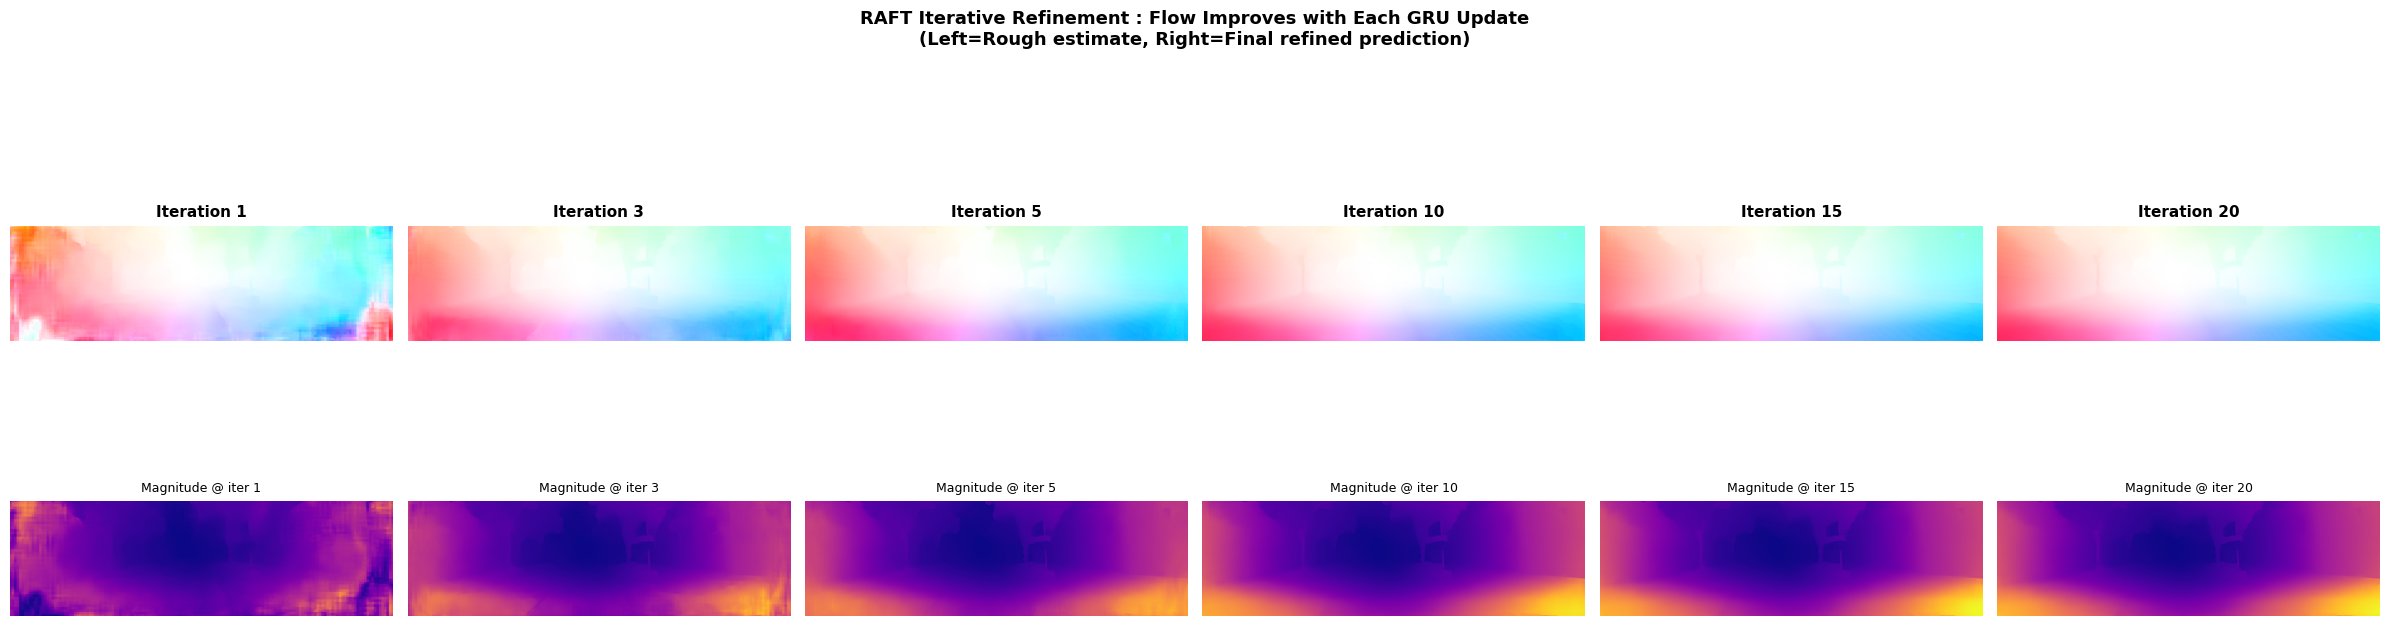

Iterative refinement visualization saved


In [17]:
# ITERATIVE REFINEMENT VISUALIZATION

@torch.no_grad()
def get_flow_at_iterations(model, frame1, frame2, device,
                            iter_checkpoints=[1, 3, 5, 10, 15, 20]):
    img1 = preprocess_for_raft(frame1, device)
    img2 = preprocess_for_raft(frame2, device)

    padder = InputPadder(img1.shape)
    img1_pad, img2_pad = padder.pad(img1, img2)

    # Run with maximum iterations and capture all intermediate predictions
    max_iters = max(iter_checkpoints)
    flow_predictions = model(img1_pad, img2_pad, iters=max_iters, test_mode=False)

    # flow_predictions is a list of all intermediate flows
    # [flow_iter1, flow_iter2, ..., flow_iterN]
    flows_at_checkpoints = {}

    for iter_num in iter_checkpoints:
        if iter_num <= len(flow_predictions):
            # Get flow at this iteration
            flow_t = flow_predictions[iter_num - 1]  # 0-indexed
            flow_t = padder.unpad(flow_t)
            flow_np = flow_t.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            flows_at_checkpoints[iter_num] = flow_np

    return flows_at_checkpoints


# Run on first pair to show iterative refinement
if pairs:
    print("Visualizing RAFT iterative refinement...")
    print("(Shows how flow improves with each GRU update step)")

    frame1 = load_image(pairs[0][0])
    frame2 = load_image(pairs[0][1])

    # Get flow at specific iterations
    checkpoints = [1, 3, 5, 10, 15, 20]
    flows = get_flow_at_iterations(model, frame1, frame2, device, checkpoints)

    # Visualize progression
    n_checkpoints = len(flows)
    fig, axes = plt.subplots(2, n_checkpoints, figsize=(4 * n_checkpoints, 8))

    for col, (iter_num, flow) in enumerate(flows.items()):
        # HSV visualization
        flow_hsv = flow_to_hsv_visualization(flow)
        axes[0, col].imshow(flow_hsv)
        axes[0, col].set_title(f"Iteration {iter_num}", fontweight='bold', fontsize=11)
        axes[0, col].axis('off')

        # Magnitude heatmap
        mag = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
        axes[1, col].imshow(mag, cmap='plasma',
                            vmin=0, vmax=flows[max(flows.keys())].__class__ and
                            np.sqrt(flows[max(flows.keys())][:,:,0]**2 +
                                   flows[max(flows.keys())][:,:,1]**2).max())
        axes[1, col].set_title(f"Magnitude @ iter {iter_num}", fontsize=9)
        axes[1, col].axis('off')

    # Labels
    axes[0, 0].set_ylabel("HSV Flow", fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel("Magnitude", fontsize=12, fontweight='bold')

    plt.suptitle(
        "RAFT Iterative Refinement : Flow Improves with Each GRU Update\n"
        "(Left=Rough estimate, Right=Final refined prediction)",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/raft/iterative_refinement.png", bbox_inches='tight', dpi=150)
    plt.show()
    print("Iterative refinement visualization saved")

In [19]:
# SAVE RAFT RESULTS SUMMARY FOR RAFT

raft_summary = {
    'method': 'RAFT (Deep Learning)',
    'type': 'Deep Learning Dense',
    'architecture': 'Recurrent All-Pairs Field Transforms',
    'parameters': '5.3M',
    'training_data': 'FlyingChairs + FlyingThings3D + KITTI (fine-tuned)',
    'pairs_evaluated': len(raft_results),
    'mean_inference_time': float(np.mean([r['inference_time'] for r in raft_results])),
    'mean_magnitude': float(np.mean([r['mean_magnitude'] for r in raft_results])),
    'advantages': [
        'Handles large motion (no small-motion assumption)',
        'Dense flow for every pixel',
        'Robust to illumination changes',
        'Iterative refinement improves accuracy progressively',
        'State-of-the-art on KITTI and Sintel benchmarks'
    ],
    'disadvantages': [
        'Requires GPU for reasonable speed',
        'Needs pretrained weights (training data required)',
        'Slower than classical methods on CPU',
        'Black box — less mathematically interpretable'
    ]
}

with open(f"{OUTPUT_DIR}/raft_results_summary.json", 'w') as f:
    json.dump(raft_summary, f, indent=2)

# Save flow results as numpy files for Notebook 3
for result in raft_results:
    np.save(
        f"{OUTPUT_DIR}/raft/flow_pair_{result['pair_id']:02d}.npy",
        result['flow']
    )

print("RAFT results saved")


RAFT results saved
